# Spectral Graph Convolution in GNNs

Steps are:
1. Transform signal to Fourier domain: $U^\top x$  
2. Apply spectral filter: $g_\theta(\Lambda)$  
3. Transform back: $U g_\theta(\Lambda) U^\top x$

**Challenges:**  

- Eigen-decomposition costs $O(n^3)$  
- Filters depend on graph → not transferable  
- Not scalable for large graphs

### Chebyshev Polynomial Filters

Avoid eigen-decomposition:

$$
g_\theta(\Lambda) \approx \sum_{k=0}^{K} \theta_k T_k(\tilde \Lambda), \quad
g_\theta * x \approx \sum_{k=0}^{K} \theta_k T_k(\tilde L) x
$$

- Efficient, scalable, no eigenvectors required

### GCN as First-Order Approximation

Kipf & Welling simplify to first-order:

$$
g_\theta(L) \approx \theta_0 I + \theta_1 L
$$
Using the normalized Laplacian, we have:
$$
\theta_0 I + \theta_1 L 
= \theta_0 I + \theta_1(I - D^{-1/2} A D^{-1/2})
$$
Let the two parameters be tied into one: $\theta = \theta_0 = -\theta_1$

This gives:
$$
g_\theta(L) \approx \theta (I + D^{-1/2} A D^{-1/2})
$$

Thus, the filtered signal becomes:

$$
g_\theta * x \approx \theta (I + D^{-1/2} A D^{-1/2}) x
$$
Define:

$$
\hat{A} = A + I
$$

for adding self loop. Kipf & Welling proposed to replace:

$$
I + D^{-1/2} A D^{-1/2}
\quad\longrightarrow\quad
\hat{D}^{-1/2} \hat{A} \hat{D}^{-1/2}
$$

where:$\hat{D}_{ii} = \sum_j \hat{A}_{ij}$

Replace the input signal $x$ with feature matrix $H^{(l)}$  
and introduce a learnable weight matrix $W^{(l)}$, leads to the resulting GCN layer:

$$
H^{(l+1)} 
= \sigma(\hat{D}^{-1/2} \hat{A} \hat{D}^{-1/2} H^{(l)} W^{(l)})
$$


- $H^{(0)}=X$
- $\hat{A} = A + I$, add self-loops  
- $\hat{D}_{ii} = \sum_j \hat{A}_{ij}$, normalize  
- Interpreted as a smooth low-pass spectral filter

---

![gcn](figures/gcn.png)


## Summary

- **Graph Laplacian** encodes neighborhood relations and enables diffusion  
- **Heat diffusion / exponential** gives intuition for smoothing signals  
- **Eigen-decomposition** defines graph frequency basis  
- **Chebyshev / iterative approximations** make diffusion scalable  
- **GCNs** implement low-order spectral filtering as message passing  
- **Low-pass filtering** promotes smooth feature propagation; high-frequency filtering can capture noise or sharp changes


### Node Classification with Graph Convolutional Networks (GCNs)

**Objective**: Predict a label for each node using its features and the graph structure.

---

### Inputs and Outputs

- **Input**:  
  - Node feature matrix $ \mathbf{X} \in \mathbb{R}^{N \times F} $, where:
    - $N$ = number of nodes  
    - $F$ = number of features per node  
  - Graph edge list $ \mathcal{E} $ (e.g., edge index in PyTorch Geometric)

- **Output**:  
  - Class probability matrix $ \hat{\mathbf{Y}} \in \mathbb{R}^{N \times C} $, where:
    - $C$ = number of classes

---

### GCN Forward Pass

Let $ f_\theta(\cdot) $ be a GCN model parameterized by $ \theta $. The forward pass computes:

$$
\hat{\mathbf{Y}} = f_\theta(\mathbf{X}, \mathcal{E})
$$

A typical GCN with two layers:

$$
\hat{\mathbf{Y}} = \text{softmax} \left( \mathbf{A}' \cdot \text{ReLU}(\mathbf{A}' \cdot \mathbf{X} \cdot \mathbf{W}^{(1)}) \cdot \mathbf{W}^{(2)} \right)
$$

Where:

- $ \mathbf{A}' = \tilde{\mathbf{D}}^{-1/2} \tilde{\mathbf{A}} \tilde{\mathbf{D}}^{-1/2} $ is the **normalized adjacency matrix with self-loops**
- $ \tilde{\mathbf{A}} = \mathbf{A} + \mathbf{I} $
- $ \tilde{\mathbf{D}} $ is the degree matrix of $ \tilde{\mathbf{A}} $
- $ \mathbf{W}^{(1)}, \mathbf{W}^{(2)} $ are learnable weight matrices

---

### Loss Function

The model is trained using **cross-entropy loss** on the labeled nodes:


$$
\mathcal{L} = - \frac{1}{|\mathcal{V}_L|} \sum_{i \in \mathcal{V}_L} \sum_{c=1}^C y_{ic} \log(\hat{y}_{ic})
$$
Where:

- $ \mathcal{V}_L $ is the set of labeled nodes
- $ y_i $ is the true label for node $i$
- $ \hat{y}_{i, y_i} $ is the predicted probability for the correct class

Epoch 001, Loss: 1.9330, Train Acc: 0.9286, Val Acc: 0.6380, Test Acc: 0.6650
Epoch 020, Loss: 0.0060, Train Acc: 1.0000, Val Acc: 0.7680, Test Acc: 0.7870
Epoch 040, Loss: 0.0051, Train Acc: 1.0000, Val Acc: 0.7820, Test Acc: 0.7940
Epoch 060, Loss: 0.0122, Train Acc: 1.0000, Val Acc: 0.7840, Test Acc: 0.8110
Epoch 080, Loss: 0.0106, Train Acc: 1.0000, Val Acc: 0.7800, Test Acc: 0.8080
Epoch 100, Loss: 0.0098, Train Acc: 1.0000, Val Acc: 0.7820, Test Acc: 0.8150
Epoch 120, Loss: 0.0090, Train Acc: 1.0000, Val Acc: 0.7780, Test Acc: 0.8130
Epoch 140, Loss: 0.0084, Train Acc: 1.0000, Val Acc: 0.7780, Test Acc: 0.8130
Epoch 160, Loss: 0.0080, Train Acc: 1.0000, Val Acc: 0.7780, Test Acc: 0.8110
Epoch 180, Loss: 0.0077, Train Acc: 1.0000, Val Acc: 0.7780, Test Acc: 0.8040
Epoch 200, Loss: 0.0074, Train Acc: 1.0000, Val Acc: 0.7760, Test Acc: 0.8040

✅ Best Validation Accuracy: 0.7880
🧪 Test Accuracy at Best Validation: 0.8080


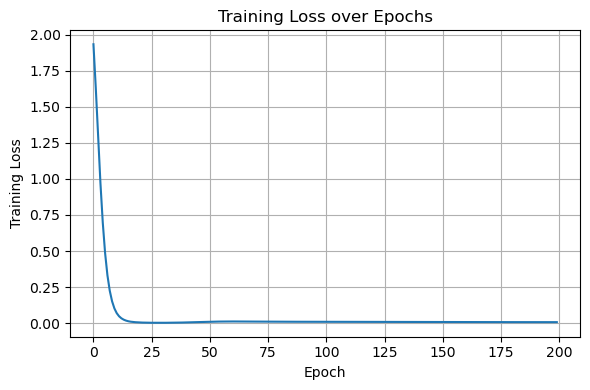

In [1]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
import matplotlib.pyplot as plt

# Load dataset
dataset = Planetoid(root='data/Planetoid', name='Cora')
data = dataset[0]

# Define the GCN model
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x

# Instantiate model, optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCN(dataset.num_node_features, 64, dataset.num_classes).to(device)
data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# Training function
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# Evaluation function
def test():
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

    accs = []
    for mask in [data.train_mask, data.val_mask, data.test_mask]:
        correct = pred[mask].eq(data.y[mask]).sum().item()
        acc = correct / mask.sum().item()
        accs.append(acc)
    return accs  # [train_acc, val_acc, test_acc]

# === Training Loop ===
train_losses = []
val_accuracies = []
best_val_acc = 0
best_test_acc = 0

for epoch in range(1, 201):
    loss = train()
    train_acc, val_acc, test_acc = test()
    train_losses.append(loss)
    val_accuracies.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_test_acc = test_acc  # Save test acc at best val

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d}, Loss: {loss:.4f}, "
              f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")

# Final Results
print("\n✅ Best Validation Accuracy: {:.4f}".format(best_val_acc))
print("🧪 Test Accuracy at Best Validation: {:.4f}".format(best_test_acc))

# Plot training loss
plt.figure(figsize=(6, 4))
plt.plot(train_losses)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.tight_layout()
plt.show()


| Task                    | Description                                      | Output                  |
| ----------------------- | ------------------------------------------------ | ----------------------- |
| **Link Prediction**     | Predict whether an edge exists between two nodes | Binary classification   |
| **Edge Classification** | Predict a label for an edge                      | Multi-class (or binary) |
| **Node Regression**     | Predict a continuous value per node              | Real-valued scalar      |
| **Graph Regression**    | Predict a continuous value per graph             | Real-valued scalar      |


## Oversmoothing: Why Deep GNNs Fail

In GNNs, we often want to increase the number of layers to capture more complex patterns and improve learning capacity. However, **adding too many layers is not always beneficial**. Beyond a certain depth, node representations start to collapse, different nodes become nearly identical, and the model loses its ability to separate classes. This phenomenon is known as **oversmoothing**.

### What Is Oversmoothing?

Oversmoothing refers to the situation where **repeated message passing causes node embeddings to converge to the same vector**, even for nodes that are far apart or belong to different classes.

Formally, for a GNN layer:

$$
H^{(l+1)} = \hat{P} H^{(l)}, 
\quad \text{with} \quad 
\hat{P} = \hat{D}^{-1/2} \hat{A} \hat{D}^{-1/2},
$$

we have:

$$
\lim_{l \to \infty} H^{(l)} = c \mathbf{1},
$$

where all rows of $H^{(l)}$ become equal.  
The graph structure essentially vanishes; all nodes look the same.

<hr>

### Oversmoothing as Repeated Laplacian Smoothing

We have:

$$
L_{\text{norm}} = I - \hat{D}^{-1/2} \hat{A} \hat{D}^{-1/2}.
$$

Therefore, a GCN layer is equivalent to **Laplacian smoothing**:

$$
H^{(l+1)} \approx (I - L_{\text{norm}}) H^{(l)}.
$$

Applying this multiple times:

$$
H^{(l)} \approx (I - L_{\text{norm}})^l H^{(0)}.
$$

As $l$ increases:

- High-frequency components decay rapidly.  
- Only the lowest eigenvector survives.  
- Node features lose variation and converge.

This is similar to **low-pass filtering applied repeatedly**: eventually, everything becomes flat.

<hr>

### Spectral Analysis: What Happens to Frequencies?

Let the propagation matrix be:

$$
\hat{P} = \hat{D}^{-1/2}\hat{A}\hat{D}^{-1/2}.
$$

Eigen-decomposition:

$$
\hat{P} = U \Lambda U^\top,
$$

with eigenvalues:

$$
1 = \lambda_1 > \lambda_2 \ge \cdots \ge \lambda_n \ge -1.
$$

After $l$ layers:

$$
H^{(l)} = \hat{P}^l H^{(0)} = U \Lambda^l U^\top H^{(0)}.
$$

As $l$ grows:

- $\lambda_1^l = 1$ remains,  
- all other $\lambda_i^l \to 0$.

Thus:

$$
H^{(l)} \to u_1 u_1^\top H^{(0)},
$$

a **rank-1** representation.  
All nodes collapse along the first eigenvector of $\hat{P}$ — the smoothest signal.  
This is the **spectral signature of oversmoothing**.

<hr>

### Connection to Heat Diffusion

Recall heat diffusion:

$$
x(t) = e^{-tL} x(0).
$$

For large $t$:

$$
e^{-tL} \to \mathbf{1} \pi^\top,
$$

where $\pi$ is the stationary distribution.

Interpretation:

- Small $t$: local smoothing.  
- Large $t$: all nodes reach the same value.

Deep GNNs behave like **heat diffusion with large $t$**, erasing information.

<hr>

### Simple Numerical Illustration

Consider a 3-node chain:

$$
1 - 2 - 3
$$

Initial signal:

$$
x^{(0)} = [1, 0, -1].
$$

After 1 smoothing step:

$$
x^{(1)} \approx [0.66, 0, -0.66]
$$

After 5 steps:

$$
x^{(5)} \approx [0.08, 0, -0.08]
$$

After 20 steps:

$$
x^{(20)} \approx [0, 0, 0]
$$

All variation disappears.

<hr>

### Why Oversmoothing Harms Learning

- Class boundaries vanish.  
- Node clustering becomes impossible.  
- Deeper layers do not add new information.  
- Gradients may vanish.  

The model becomes almost constant and loses expressive power.

<hr>

### Practical Advice

- **Few layers are usually sufficient**: typically 2–4 layers in standard GCNs.  
- To go deeper, consider methods like **residual connections, DropEdge, GCNII, APPNP, or Graph Transformers** to mitigate oversmoothing.

<hr>

### Summary

- Oversmoothing: collapse of node embeddings into nearly identical vectors.  
- Arises from repeated application of normalized adjacency matrices.  
- Spectral view: all but the smallest eigenvalue vanish.  
- Analogy: heat diffusion with large time $t$.  
- Sets a fundamental limit on how deep standard GCNs can be.
